In [332]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

In [333]:
df_all = pd.read_csv('prices-split-adjusted.csv', parse_dates=True)

In [88]:
df_all.shape

(851264, 7)

In [74]:
df_all.head(10)

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0
5,2016-01-12,WLTW,115.510002,115.550003,114.500000,116.059998,1098000.0
6,2016-01-13,WLTW,116.459999,112.849998,112.589996,117.070000,949600.0
7,2016-01-14,WLTW,113.510002,114.379997,110.050003,115.029999,785300.0
8,2016-01-15,WLTW,113.330002,112.529999,111.919998,114.879997,1093700.0
9,2016-01-19,WLTW,113.660004,110.379997,109.870003,115.870003,1523500.0


In [5]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    851264 non-null  object 
 1   symbol  851264 non-null  object 
 2   open    851264 non-null  float64
 3   close   851264 non-null  float64
 4   low     851264 non-null  float64
 5   high    851264 non-null  float64
 6   volume  851264 non-null  float64
dtypes: float64(5), object(2)
memory usage: 45.5+ MB


In [6]:
df_all.describe().T

,count,mean,std,min,25%,50%,75%,max
open,851264.0,6.499362e+01,7.520389e+01,1.66,3.127000e+01,4.846000e+01,7.512000e+01,1.584440e+03
close,851264.0,6.501191e+01,7.520122e+01,1.59,3.129278e+01,4.848000e+01,7.514000e+01,1.578130e+03
low,851264.0,6.433654e+01,7.445952e+01,1.50,3.094000e+01,4.797000e+01,7.440000e+01,1.549940e+03
high,851264.0,6.563975e+01,7.590686e+01,1.81,3.162000e+01,4.896000e+01,7.585000e+01,1.600930e+03
volume,851264.0,5.415113e+06,1.249468e+07,0.00,1.221500e+06,2.476250e+06,5.222500e+06,8.596434e+08


In [7]:
df_all.isnull().sum()

,0
date,0
symbol,0
open,0
close,0
low,0
high,0
volume,0


In [334]:
# WLTW
data = df_all[['date', 'open', 'close']][df_all['symbol']=='WLTW']
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)

# Находим недостающие даты и добавляем в датафрейм
all_days = pd.date_range(start=data.index.min(), end=data.index.max(), freq='D')
df_all_days = data.reindex(all_days)
df_filled = df_all_days.fillna({'open': 0, 'close': 0})

# Заполняем недостающие даты предыдущими значениями open и close
df = df_filled.copy()
df['open'].replace(0, pd.NA, inplace=True)
df['close'].replace(0, pd.NA, inplace=True)

df['open'] = df['open'].fillna(method='ffill')
df['close'] = df['close'].fillna(method='ffill')

df['open'].replace(0, pd.NA, inplace=True)
df['close'].replace(0, pd.NA, inplace=True)

df['open'] = df['open'].fillna(method='ffill')
df['close'] = df['close'].fillna(method='ffill')

df['open'].replace(0, pd.NA, inplace=True)
df['close'].replace(0, pd.NA, inplace=True)

df['open'] = df['open'].fillna(method='ffill')
df['close'] = df['close'].fillna(method='ffill')

df = df.reset_index().rename(columns={'index':'date'})
df.head(10)

,date,open,close
0,2016-01-05,123.430000,125.839996
1,2016-01-06,125.239998,119.980003
2,2016-01-07,116.379997,114.949997
3,2016-01-08,115.480003,116.620003
4,2016-01-09,115.480003,116.620003
5,2016-01-10,115.480003,116.620003
6,2016-01-11,117.010002,114.970001
7,2016-01-12,115.510002,115.550003
8,2016-01-13,116.459999,112.849998
9,2016-01-14,113.510002,114.379997


In [335]:
# Объединяем поля open и close
df_open = df[['date', 'open']].copy()
df_open['type'] = 'open'
df_open.rename(columns={'open': 'value'}, inplace=True)

df_close = df[['date', 'close']].copy()
df_close['type'] = 'close'
df_close.rename(columns={'close': 'value'}, inplace=True)

df_combined = pd.concat([df_open, df_close])
df_combined.sort_values(by=['date', 'type'], inplace=True, ascending=[True, False])
df_combined = df_combined.reset_index(drop=True)
df_combined['date'] = pd.to_datetime(df_combined['date'])

df_combined.head(10)

,date,value,type
0,2016-01-05,123.430000,open
1,2016-01-05,125.839996,close
2,2016-01-06,125.239998,open
3,2016-01-06,119.980003,close
4,2016-01-07,116.379997,open
5,2016-01-07,114.949997,close
6,2016-01-08,115.480003,open
7,2016-01-08,116.620003,close
8,2016-01-09,115.480003,open
9,2016-01-09,116.620003,close


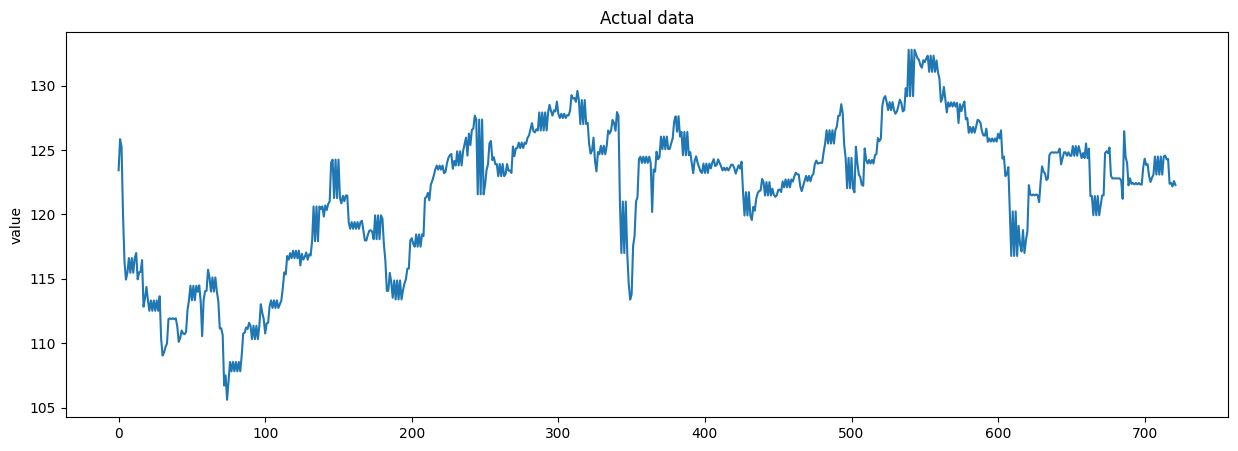

In [260]:
df_combined = df_combined[['date', 'value']]

plt.figure(figsize=(15, 5))
plt.plot(df_combined['value'])
plt.ylabel('value')
plt.title('Actual data')
plt.show()

# Тренд Сезонность Цикличность

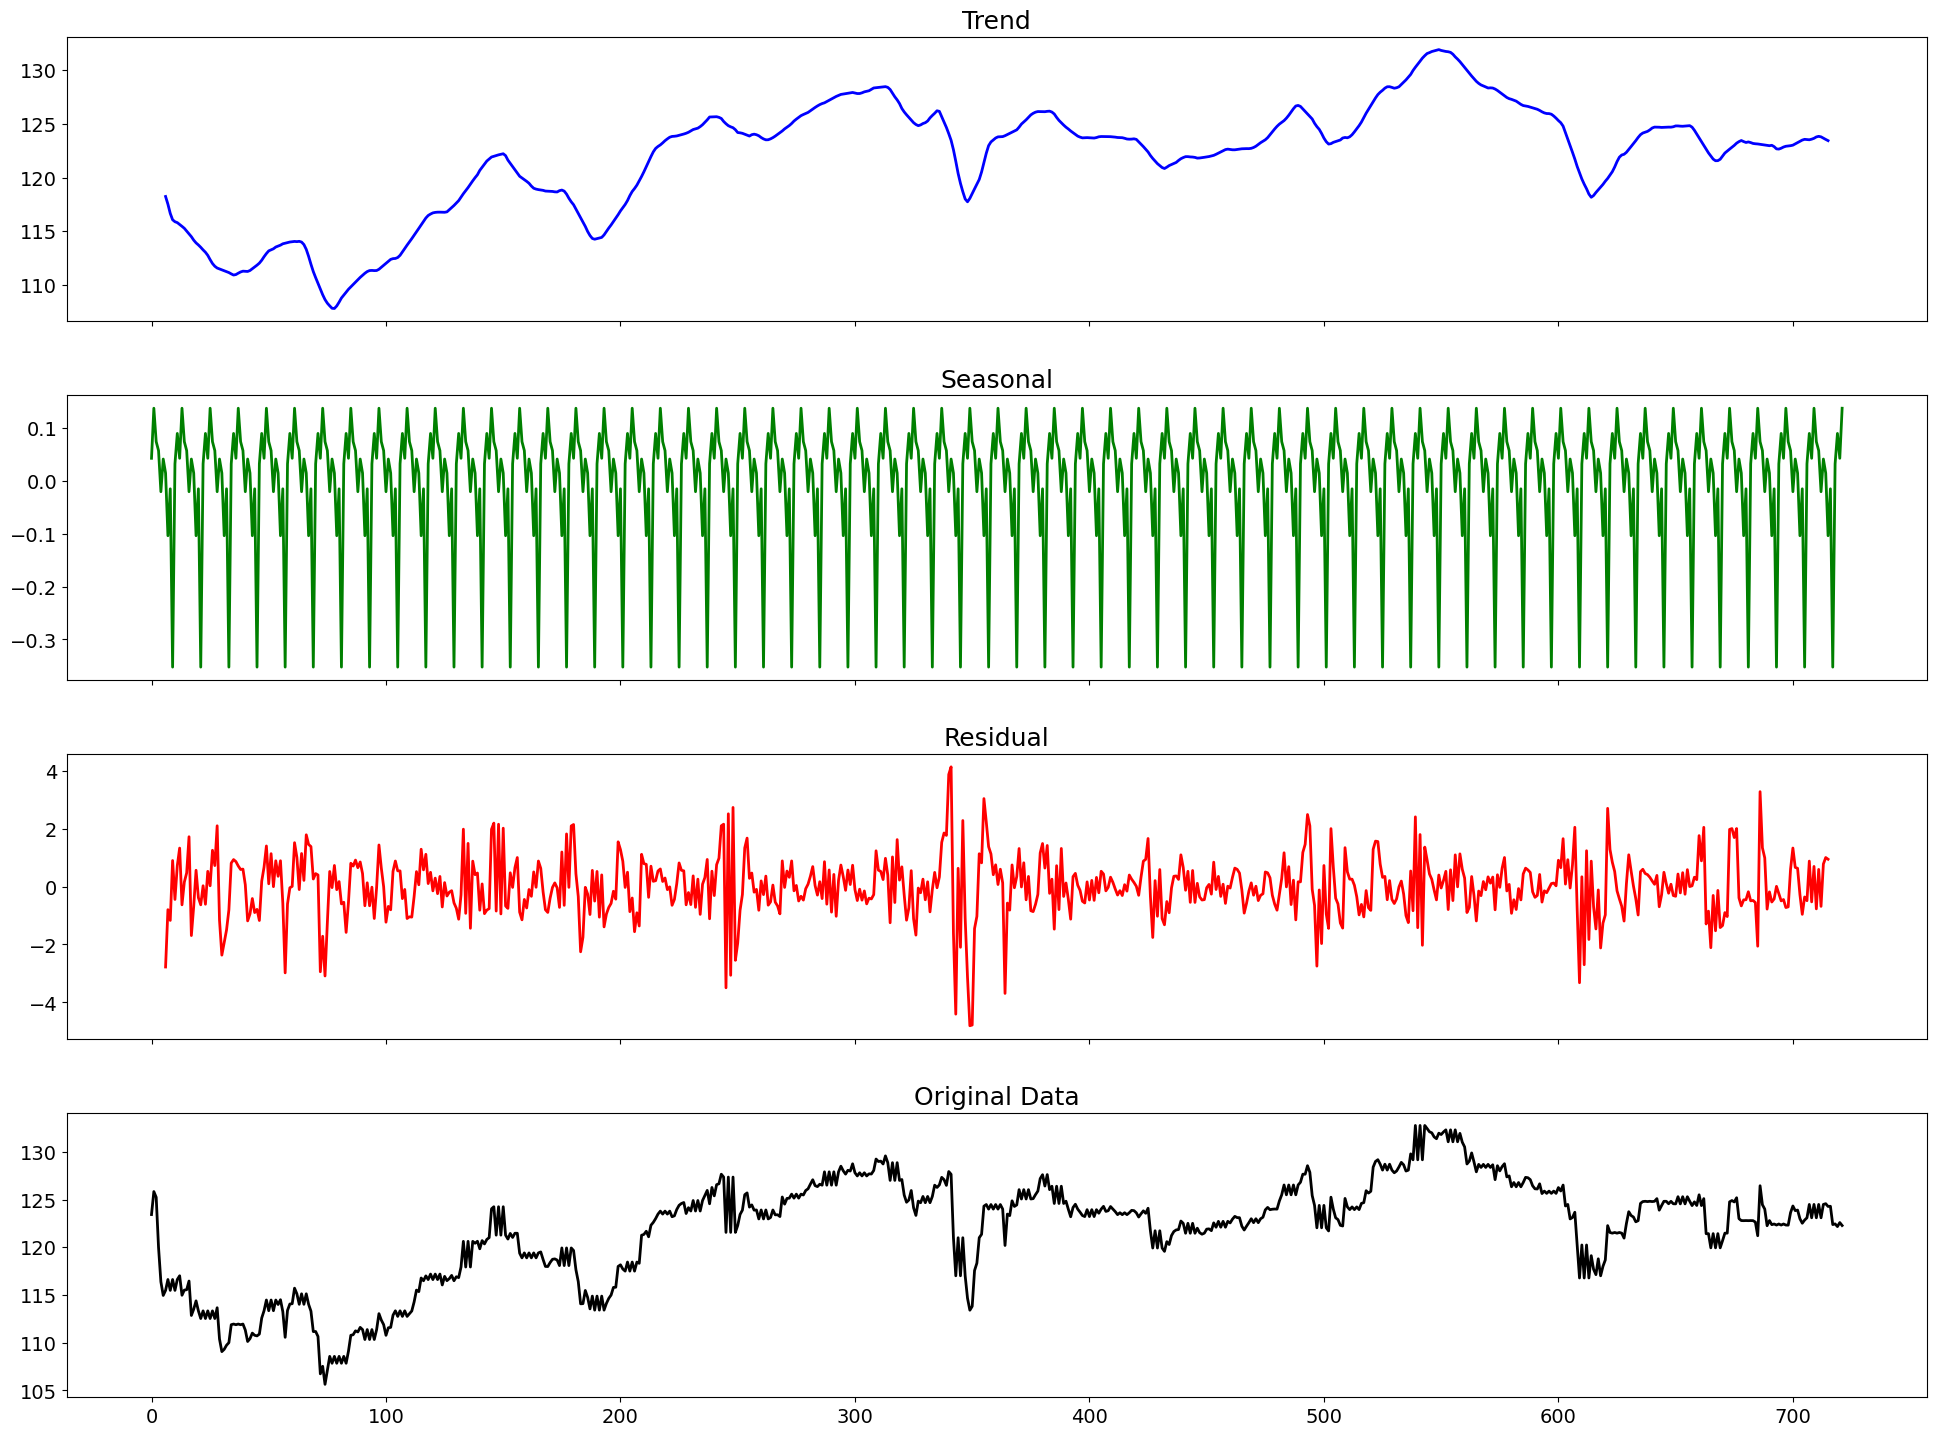

In [53]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(data['value'], model='additive', period=12)
fig, axes = plt.subplots(4, 1, figsize=(20, 15), sharex=True)

# Тренд
axes[0].plot(result.trend, color='blue', linewidth=2)
axes[0].set_title('Trend', fontsize=18)
axes[0].tick_params(axis='both', which='major', labelsize=14)

# Сезонность
axes[1].plot(result.seasonal, color='green', linewidth=2)
axes[1].set_title('Seasonal', fontsize=18)
axes[1].tick_params(axis='both', which='major', labelsize=14)

# Остаток
axes[2].plot(result.resid, color='red', linewidth=2)
axes[2].set_title('Residual', fontsize=18)
axes[2].tick_params(axis='both', which='major', labelsize=14)

# Оригинальные данные
axes[3].plot(result.observed, color='black', linewidth=2)
axes[3].set_title('Original Data', fontsize=18)
axes[3].tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout(pad=3.0)
plt.show()


# Тест Дики-Фуллера

In [336]:
from statsmodels.tsa.stattools import adfuller

test = adfuller(df_combined['value'])
print('Критерий ADF: %f' % test[0])
print('P-значение: %f' % test[1])
print('Критические значения:')
for key, value in test[4].items():
  print('\t%s: %.3f' % (key, value))

if test[0] < test[4]["5%"]:
  print ("Нулевая гипотеза отвергается, ряд стационарен.")
else:
  print ("Нулевая гипотеза не отвергается, ряд не стационарен.")

Критерий ADF: -2.164127
P-значение: 0.219522
Критические значения:
	1%: -3.440
	5%: -2.866
	10%: -2.569
Нулевая гипотеза не отвергается, ряд не стационарен.


In [337]:
df_combined.set_index('date', inplace=True)
df_combined.head()

,value,type
date,,
2016-01-05,123.430000,open
2016-01-05,125.839996,close
2016-01-06,125.239998,open
2016-01-06,119.980003,close
2016-01-07,116.379997,open


# Модель ARIMA без преобразования данных

In [341]:
df_combined.index = pd.to_datetime(df_combined.index)
start_date = pd.to_datetime('2016-12-01')
train = df_combined[df_combined.index < start_date]  
test = df_combined[df_combined.index >= start_date] 


In [ ]:
!pip install optuna

In [328]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import itertools

In [314]:
p = q = range(1, 40)
d = range(1, 3)
pdq = list(itertools.product(p, d, q))

def objective_arima(trial):
    order = trial.suggest_categorical('order', pdq)
    model = ARIMA(train, order=order)
    mdl = model.fit()
    predictions = mdl.forecast(len(test))
    mae = mean_absolute_error(test, predictions)
    return mae

study = optuna.create_study(direction="minimize")
study.optimize(objective_arima, n_trials=50)

[I 2024-08-13 16:30:36,325] A new study created in memory with name: no-name-c6edd689-6eb9-4157-a7a7-4c789a228511
[W 2024-08-13 16:30:36,376] Trial 0 failed with parameters: {'order': (6, 1, 37)} because of the following error: ValueError('Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).').
Traceback (most recent call last):
  File "C:\Users\User\PycharmProjects\TMSds1\.venv\Lib\site-packages\optuna\study\_optimize.py", line 196, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\User\AppData\Local\Temp\ipykernel_19284\3296388118.py", line 7, in objective_arima
    model = ARIMA(train, order=order)
            ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\PycharmProjects\TMSds1\.venv\Lib\site-packages\statsmodels\tsa\arima\model.py", line 158, in __init__
    self._spec_arima = SARIMAXSpecification(
                       ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\PycharmProjects\TMSds1\.venv\Lib\site-

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [343]:
p, d, q = 36, 1, 38

model = ARIMA(train, order=(p, d, q))
mdl = model.fit()
pred = mdl.forecast(len(test))
error = mean_absolute_error(test, pred)
print('MAE =', error)

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [98]:
real_direction = np.sign(test.diff().dropna())  
predicted_direction = np.sign(np.diff(pred))  
real_direction = real_direction[1:]
predicted_direction = predicted_direction[:len(real_direction)]

accuracy_direction = np.mean(real_direction == predicted_direction)
print("Accuracy of Direction Prediction:", accuracy_direction)


Accuracy of Direction Prediction: 0.49197384066587396


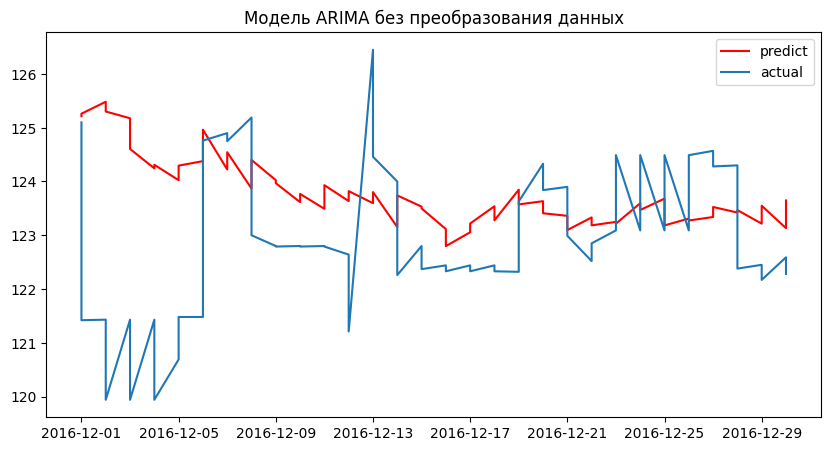

In [99]:
plt.figure(figsize=(10,5))
plt.plot(test.index, pred, 'r', label = 'predict')
plt.plot(test.index, test, label = 'actual')
plt.title('Модель ARIMA без преобразования данных')
plt.legend()
plt.show()

# Логарифмирование + Дифференцирование

## Логарифмирование

In [344]:
data1 = df_combined.copy()
data_log = np.log(data1['value'])

test = adfuller(data_log)
print('Тест Дики-Фуллера:')
print('Критерий ADF: %f' % test[0])
print('P-значение: %f' % test[1])
for key, value in test[4].items():
  print('\t%s: %.3f' % (key, value))

if test[0] < test[4]["5%"]:
  print ("Нулевая гипотеза отвергается, ряд стационарен.")
else:
  print ("Нулевая гипотеза не отвергается, ряд не стационарен.")

Тест Дики-Фуллера:
Критерий ADF: -2.152564
P-значение: 0.223910
	1%: -3.440
	5%: -2.866
	10%: -2.569
Нулевая гипотеза не отвергается, ряд не стационарен.


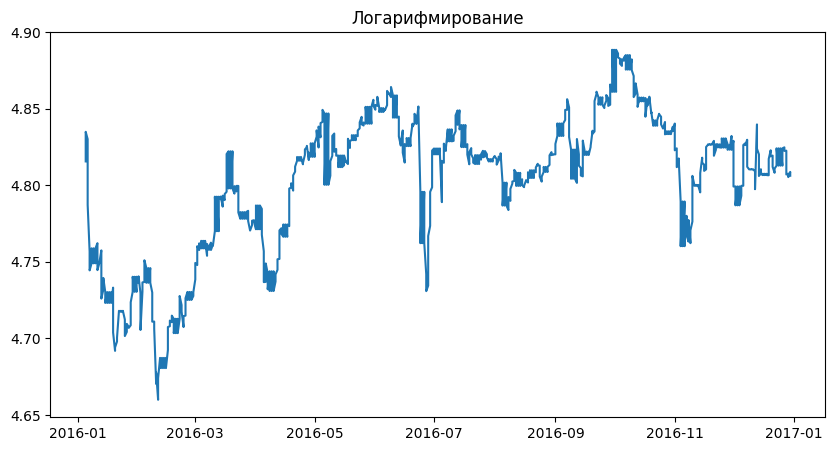

In [345]:
plt.figure(figsize=(10,5))
plt.plot(data_log)
plt.title('Логарифмирование')
plt.grid(False)
plt.show()

Обнаружение выбросов и замена их на медианное значение

In [346]:
Q1 = data_log.quantile(0.25)
Q3 = data_log.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data_log[(data_log < lower_bound) | (data_log > upper_bound)]

median_value = data_log.median()

data_log = data_log.apply(lambda x: median_value if x in outliers.values else x)


## Дифференцирование

In [347]:
data_log_diff = data_log.diff().dropna()

test = adfuller(data_log_diff)
print('Тест Дики-Фуллера:')
print('Критерий ADF: %f' % test[0])
print('P-значение: %f' % test[1])
for key, value in test[4].items():
  print('\t%s: %.3f' % (key, value))

if test[0] < test[4]["5%"]:
  print ("Нулевая гипотеза отвергается, ряд стационарен.")
else:
  print ("Нулевая гипотеза не отвергается, ряд не стационарен.")

Тест Дики-Фуллера:
Критерий ADF: -8.209661
P-значение: 0.000000
	1%: -3.440
	5%: -2.866
	10%: -2.569
Нулевая гипотеза отвергается, ряд стационарен.


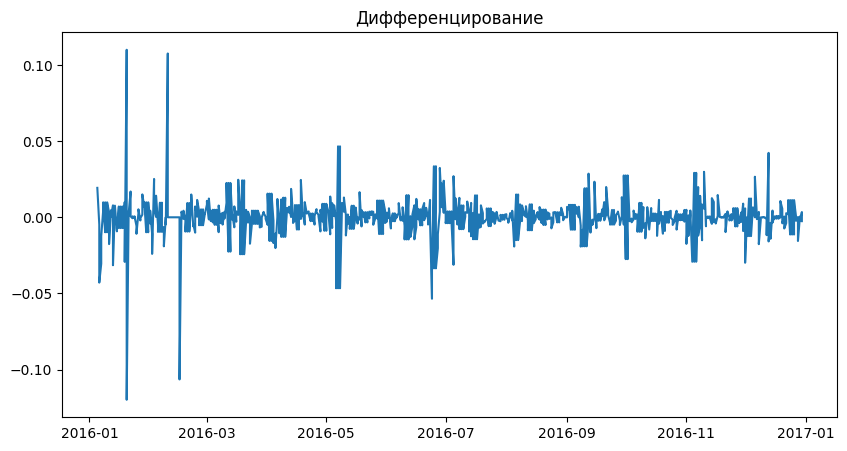

In [348]:
plt.figure(figsize=(10,5))
plt.plot(data_log_diff)
plt.title('Дифференцирование')
plt.grid(False)
plt.show()

## Модель Хольта-Винтерса

In [349]:
train = df_combined[df_combined.index<'2016-12-01']
test = df_combined[df_combined.index>='2016-12-01']

train_log_diff = data_log_diff[data_log_diff.index<'2016-12-01']
test_log_diff = data_log_diff[data_log_diff.index>='2016-12-01']

train_log = data_log[data_log.index<'2016-12-01']

In [194]:
train_log_diff

date
2016-01-05    0.019337
2016-01-06   -0.004779
2016-01-06   -0.042907
2016-01-07   -0.030464
2016-01-07   -0.012363
                ...   
2016-11-28   -0.003612
2016-11-29    0.003131
2016-11-29   -0.003051
2016-11-30    0.008964
2016-11-30   -0.009045
Name: value, Length: 661, dtype: float64

In [350]:
from statsmodels.tsa.api import ExponentialSmoothing

In [351]:
model_holt = ExponentialSmoothing(train_log_diff, damped_trend=True, trend='add',
                                  initialization_method='estimated', seasonal='add', seasonal_periods=12).fit()


In [352]:
pred_holt_log_diff = model_holt.forecast(len(test_log_diff))

In [353]:
pred_holt_log = train_log[-1] + pred_holt_log_diff.cumsum()

In [366]:
pred_holt = np.exp(pred_holt_log)

In [355]:
test= test.drop(columns='type')

In [365]:
error = mean_absolute_error(test, pred_holt)
print('MAE =', error)

MAE = 2.1709298162134587


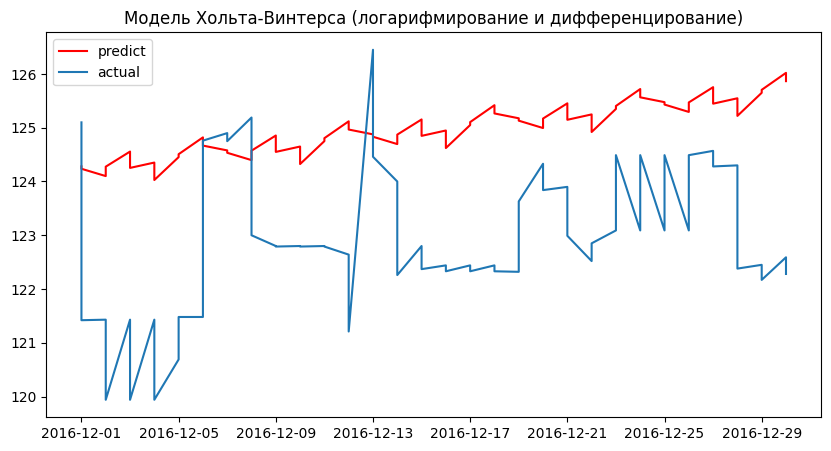

In [357]:
plt.figure(figsize=(10,5))
plt.plot(test.index, pred_holt, 'r', label = 'predict')
plt.plot(test.index, test, label = 'actual')
plt.title('Модель Хольта-Винтерса (логарифмирование и дифференцирование)')
plt.legend()
plt.show()

In [371]:
real_direction = np.sign(test.diff().dropna())
predicted_direction = np.sign(np.diff(pred_holt))

real_direction = real_direction.iloc[1:] 
predicted_direction = predicted_direction[:len(real_direction)]

accuracy_direction = np.mean(real_direction.values == predicted_direction)

print("Accuracy of Direction Prediction:", accuracy_direction)


Accuracy of Direction Prediction: 0.49108204518430437


## Модель ARIMA

In [ ]:
p = q = range(1, 40)
d = range(0, 3)
pdq = list(itertools.product(p, d, q))

def objective_arima(trial):
    order = trial.suggest_categorical('order', pdq)
    model = ARIMA(train_log_diff, order=order)
    mdl = model.fit()
    pred_arima = mdl.forecast(len(test_log_diff))
    pred_log = train_log[-1] + pred_arima.cumsum()
    pred = np.exp(pred_log)
    mae = mean_absolute_error(test, pred)
    return mae

study = optuna.create_study(direction="minimize")
study.optimize(objective_arima, n_trials=100)

In [226]:
p, d, q = 7, 2, 5

model = ARIMA(train_log_diff, order=(p, d, q))
mdl = model.fit()
pred_arima = mdl.forecast(len(test_log_diff))
pred_log = train_log[-1] + pred_arima.cumsum()
pred = np.exp(pred_log)

error = mean_absolute_error(test, pred)
print('MAE =', error)

MAE = 1.4715312520809893


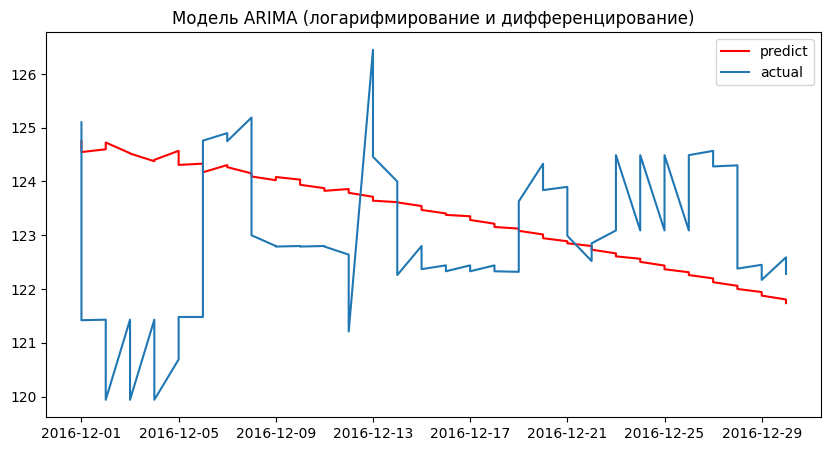

In [227]:
plt.figure(figsize=(10,5))
plt.plot(test.index, pred, 'r', label = 'predict')
plt.plot(test.index, test, label = 'actual')
plt.title('Модель ARIMA (логарифмирование и дифференцирование)')
plt.legend()
plt.show()

In [228]:
real_direction = np.sign(test.diff().dropna())
predicted_direction = np.sign(np.diff(pred))
real_direction = real_direction.iloc[1:]  
predicted_direction = predicted_direction[:len(real_direction)]
accuracy_direction = np.mean(real_direction.values == predicted_direction)

print("Accuracy of Direction Prediction:", accuracy_direction)


Accuracy of Direction Prediction: 0.4976218787158145


## Модель SARIMA

In [229]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
def objective_sarima(trial):
    p = q = range(1, 40)
    d = range(0, 3)
    s = range(12, 13)
    pdq = list(itertools.product(p, d, q))
    pdqs = list(itertools.product(p, d, q, s))
    order = trial.suggest_categorical('order', pdq)
    seasonal_order = trial.suggest_categorical('seasonal_order', pdqs)

    try:
        model = SARIMAX(train_log_diff, order=order, seasonal_order=seasonal_order)
        mdl = model.fit()
        pred_sarima = mdl.forecast(len(test_log_diff))
        pred_log = train_log[-1] + pred_sarima.cumsum()
        pred = np.exp(pred_log)
        mae = mean_absolute_error(test, pred)

    except Exception as e:
        print(f'Ошибка: {e}')
        mae = float('inf')

    return mae

study = optuna.create_study(direction="minimize")
study.optimize(objective_sarima, n_trials=100)

In [230]:
p, d, q = 4, 1, 2
P, D, Q, s = 14, 1, 6, 12

model = SARIMAX(train_log_diff, order=(p, d, q), seasonal_order=(P, D, Q, s))
mdl = model.fit()
pred_sarima = mdl.forecast(len(test_log_diff))
pred_log = train_log[-1] + pred_sarima.cumsum()
pred = np.exp(pred_log)

mae = mean_absolute_error(test, pred)
print('MAE =', mae)

MAE = 1.395018070549734


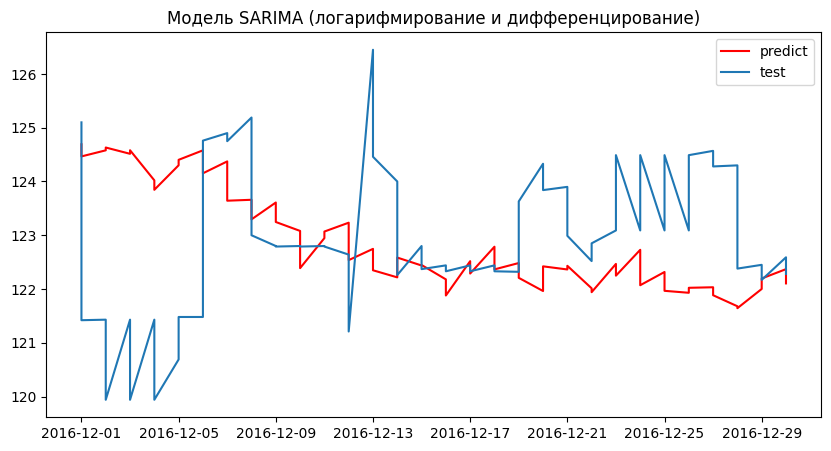

In [231]:
plt.figure(figsize=(10,5))
plt.plot(test.index, pred, 'r', label = 'predict')
plt.plot(test.index, test, label = 'test')
plt.title('Модель SARIMA (логарифмирование и дифференцирование)')
plt.legend()
plt.show()

In [239]:
real_direction = np.sign(test.diff().dropna())
predicted_direction = np.sign(np.diff(pred))
real_direction = real_direction.iloc[1:]  
predicted_direction = predicted_direction[:len(real_direction)]

accuracy_direction = np.mean(real_direction.values == predicted_direction)

print("Accuracy of Direction Prediction:", accuracy_direction)


Accuracy of Direction Prediction: 0.49167657550535077


# Преобразование Бокса-Кокса + Дифференцирование

## Преобразование Бокса-Кокса

In [262]:
from scipy.stats import boxcox
from scipy.special import inv_boxcox # обратное преобразование Бокса-Кокса

In [263]:
data2 = df_combined.copy()
data2['value_box'], lmbda = boxcox(data2['value'])
data_box = data2['value_box']

print('Оптимальный параметр преобразования Бокса-Кокса: %f' % lmbda)

test = adfuller(data_box)
print('Тест Дики-Фуллера:')
print('Критерий ADF: %f' % test[0])
print('P-значение: %f' % test[1])
for key, value in test[4].items():
  print('\t%s: %.3f' % (key, value))

if test[0] < test[4]["5%"]:
  print ("Нулевая гипотеза отвергается, ряд стационарен.")
else:
  print ("Нулевая гипотеза не отвергается, ряд не стационарен.")

Оптимальный параметр преобразования Бокса-Кокса: 7.445285
Тест Дики-Фуллера:
Критерий ADF: -0.429307
P-значение: 0.905089
	1%: -3.440
	5%: -2.866
	10%: -2.569
Нулевая гипотеза не отвергается, ряд не стационарен.


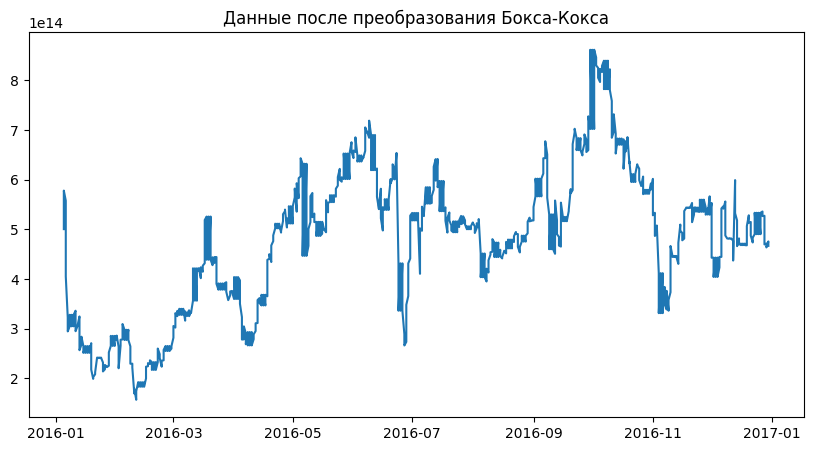

In [264]:
plt.figure(figsize=(10,5))
plt.plot(data_box)
plt.title('Данные после преобразования Бокса-Кокса')
plt.show()

Обнаружение выбросов и замена их на медианное значение

In [266]:
Q1 = data_box.quantile(0.25)
Q3 = data_box.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data_box[(data_box < lower_bound) | (data_box > upper_bound)]
median_value = data_box.median()
mask = (data_box < lower_bound) | (data_box > upper_bound)
data_box.loc[mask] = median_value

## Дифференцирование

In [267]:
data_box_diff = data_box.diff().dropna()

test = adfuller(data_box_diff)
print('Тест Дики-Фуллера:')
print('Критерий ADF: %f' % test[0])
print('P-значение: %f' % test[1])
for key, value in test[4].items():
  print('\t%s: %.3f' % (key, value))

if test[0] < test[4]["5%"]:
  print ("Нулевая гипотеза отвергается, ряд стационарен.")
else:
  print ("Нулевая гипотеза не отвергается, ряд не стационарен.")

Тест Дики-Фуллера:
Критерий ADF: -10.312468
P-значение: 0.000000
	1%: -3.440
	5%: -2.866
	10%: -2.569
Нулевая гипотеза отвергается, ряд стационарен.


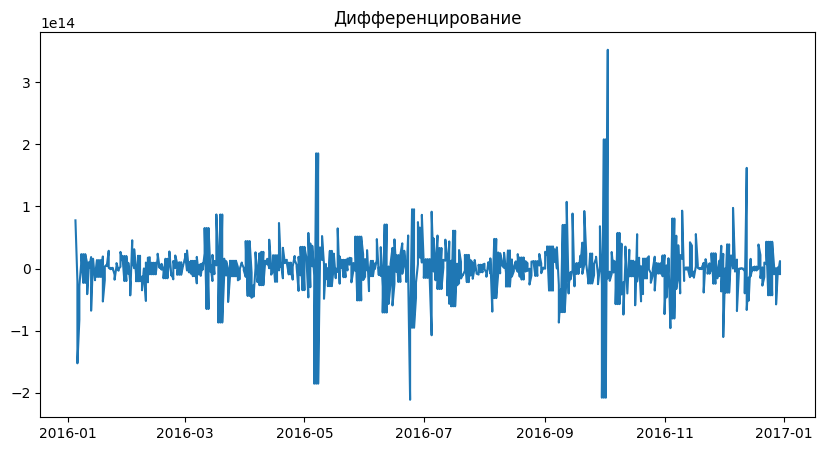

In [268]:
plt.figure(figsize=(10,5))
plt.plot(data_box_diff)
plt.title('Дифференцирование')
plt.grid(False)
plt.show()

## Модель ARIMA

In [269]:
train = df_combined[df_combined.index<'2016-12-01']
test = df_combined[df_combined.index>='2016-12-01']

train_box_diff = data_box_diff[data_box_diff.index<'2016-12-01']
test_box_diff = data_box_diff[data_box_diff.index>='2016-12-01']

train_box = data_box[data_box.index<'2016-12-01']

In [ ]:
p = q = range(1, 40)
d = range(1, 3)
pdq = list(itertools.product(p, d, q))


def objective_arima(trial):
    order = trial.suggest_categorical('order', pdq)
    model = ARIMA(train_box_diff, order=order)
    mdl = model.fit()
    pred_box_diff = mdl.forecast(len(test_box_diff))
    pred_box = train_box[-1] + pred_box_diff.cumsum()
    pred = inv_boxcox(pred_box, lmbda)
    mae = mean_absolute_error(test, pred)
    return mae

study = optuna.create_study(direction="minimize")
study.optimize(objective_arima, n_trials=100)

In [279]:
p, d, q = 10, 2, 31

model = ARIMA(train_box_diff, order=(p, d, q))
mdl = model.fit()
pred_box_diff = mdl.forecast(len(test_box_diff))
pred_box = train_box[-1] + pred_box_diff.cumsum()
pred = inv_boxcox(pred_box, lmbda)

error = mean_absolute_error(test, pred)
print('MAE =', error)

MAE = 1.4963936198509975


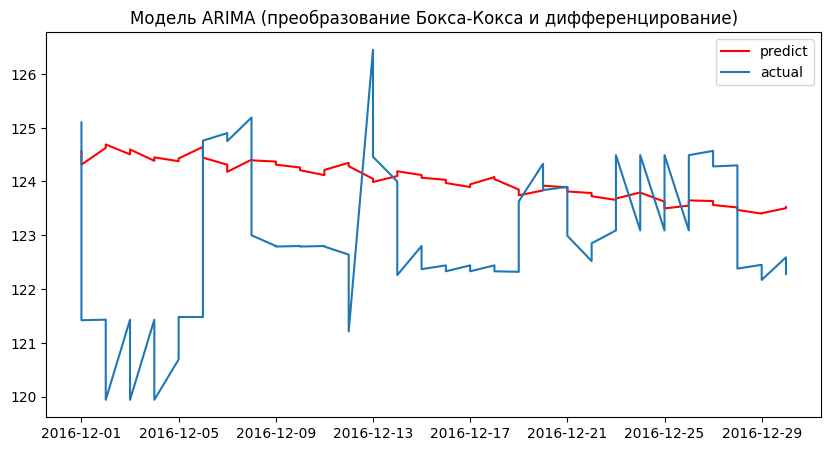

In [280]:
plt.figure(figsize=(10,5))
plt.plot(test.index, pred, 'r', label = 'predict')
plt.plot(test.index, test, label = 'actual')
plt.title('Модель ARIMA (преобразование Бокса-Кокса и дифференцирование)')
plt.legend()
plt.show()

In [281]:
real_direction = np.sign(test.diff().dropna())
predicted_direction = np.sign(np.diff(pred))
real_direction = real_direction.iloc[1:]  
predicted_direction = predicted_direction[:len(real_direction)]
accuracy_direction = np.mean(real_direction.values == predicted_direction)

print("Accuracy of Direction Prediction:", accuracy_direction)


Accuracy of Direction Prediction: 0.4937574316290131


## Модель Хольта-Винтерса

In [282]:
from statsmodels.tsa.api import ExponentialSmoothing

In [300]:
model_holt = ExponentialSmoothing(train_box_diff, damped_trend=True, trend='add',
                                  initialization_method='estimated', seasonal='add', seasonal_periods=36).fit()

pred_box_diff = model_holt.forecast(len(test_box_diff))
pred_box = train_box[-1] + pred_box_diff.cumsum()
pred_holt = inv_boxcox(pred_box, lmbda)

error = mean_absolute_error(test, pred_holt)
print('MAE =', error)

MAE = 1.6591272699285966


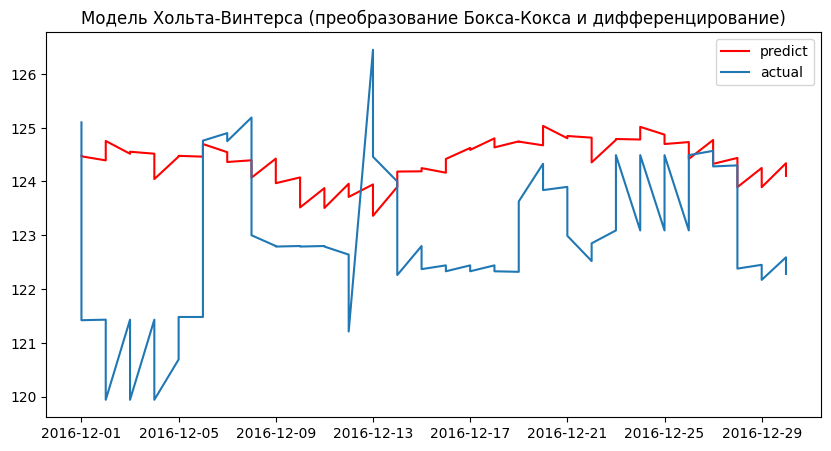

In [301]:
plt.figure(figsize=(10,5))
plt.plot(test.index, pred_holt, 'r', label = 'predict')
plt.plot(test.index, test, label = 'actual')
plt.title('Модель Хольта-Винтерса (преобразование Бокса-Кокса и дифференцирование)')
plt.legend()
plt.show()

In [302]:
real_direction = np.sign(test.diff().dropna())
predicted_direction = np.sign(np.diff(pred_holt))
real_direction = real_direction.iloc[1:]  
predicted_direction = predicted_direction[:len(real_direction)]
accuracy_direction = np.mean(real_direction.values == predicted_direction)

print("Accuracy of Direction Prediction:", accuracy_direction)


Accuracy of Direction Prediction: 0.49137931034482757


## Модель SARIMA

In [286]:
p, d, q = 2, 1, 2
P, D, Q, s = 4, 1, 1, 12

model = SARIMAX(train_box_diff, order=(p, d, q), seasonal_order=(P, D, Q, s))
mdl = model.fit()
pred_sarima = mdl.forecast(len(test_box_diff))
pred_box = train_box[-1] + pred_sarima.cumsum()
pred = inv_boxcox(pred_box, lmbda)

mae = mean_absolute_error(test, pred)
print('MAE =', mae)

MAE = 1.524247775374942


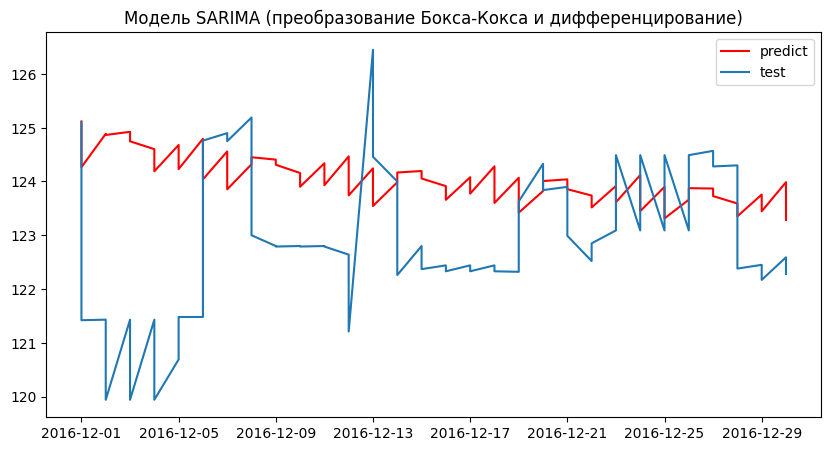

In [287]:
plt.figure(figsize=(10,5))
plt.plot(test.index, pred, 'r', label = 'predict')
plt.plot(test.index, test, label = 'test')
plt.title('Модель SARIMA (преобразование Бокса-Кокса и дифференцирование)')
plt.legend()
plt.show()

In [288]:
real_direction = np.sign(test.diff().dropna())
predicted_direction = np.sign(np.diff(pred))
real_direction = real_direction.iloc[1:]  
predicted_direction = predicted_direction[:len(real_direction)]
accuracy_direction = np.mean(real_direction.values == predicted_direction)

print("Accuracy of Direction Prediction:", accuracy_direction)


Accuracy of Direction Prediction: 0.49227110582639716


# RF

In [ ]:
data = pd.read_csv('final.csv', parse_dates=True)

In [387]:
data['Yesterday'] = data['value'].shift(1)
data['Day_Before_Yesterday'] = data['value'].shift(2)
data.fillna(0, inplace=True)
print(data.head(10))

   Unnamed: 0        date       value   type   Yesterday  Day_Before_Yesterday
0           0  2016-01-05  123.430000   open    0.000000              0.000000
1           0  2016-01-05  125.839996  close  123.430000              0.000000
2           1  2016-01-06  125.239998   open  125.839996            123.430000
3           1  2016-01-06  119.980003  close  125.239998            125.839996
4           2  2016-01-07  116.379997   open  119.980003            125.239998
5           2  2016-01-07  114.949997  close  116.379997            119.980003
6           3  2016-01-08  115.480003   open  114.949997            116.379997
7           3  2016-01-08  116.620003  close  115.480003            114.949997
8           4  2016-01-09  115.480003   open  116.620003            115.480003
9           4  2016-01-09  116.620003  close  115.480003            116.620003


In [388]:
data['value'] = pd.to_numeric(data['value'], errors='coerce')


In [389]:
import numpy as np
import pandas as pd
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import make_forecasting_frame
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')  # Вы можете выбрать другую стратегию заполнения, такую как 'median' или 'most_frequent'



# 1. Подготовка данных
df_shift, y = make_forecasting_frame(data["value"], kind="power", max_timeshift=10, rolling_direction=1)

# 2. Извлечение признаков
X = extract_features(df_shift, column_id="id", column_sort="time", column_value="value", impute_function=np.nanmean, show_warnings=False)


Feature Extraction: 100%|██████████| 15/15 [00:19<00:00,  1.28s/it]


In [397]:
X

value__variance_larger_than_standard_deviation  \
id 1                                               0.0   
   2                                               1.0   
   3                                               1.0   
   4                                               1.0   
   5                                               1.0   
...                                                ...   
   717                                             0.0   
   718                                             0.0   
   719                                             0.0   
   720                                             0.0   
   721                                             0.0   

        value__has_duplicate_max  value__has_duplicate_min  \
id 1                         0.0                       0.0   
   2                         0.0                       0.0   
   3                         0.0                       0.0   
   4                         0.0                       0.0   
   5                         0.0                       0.0   
...                          ...                       ...   
   717                       0.0                       1.0   
   718                       0.0                       0.0   
   719                       0.0                       0.0   
   720                       0.0                       0.0   
   721                       0.0                       0.0   

        value__has_duplicate  value__sum_values  value__abs_energy  \
id 1                     0.0         123.430000       15234.964900   
   2                     0.0         249.269996       31070.669493   
   3                     0.0         374.509994       46755.726592   
   4                     0.0         494.489997       61150.927712   
   5                     0.0         610.869994       74695.231414   
...                      ...                ...                ...   
   717                   1.0        1240.379982      153858.173551   
   718                   1.0        1238.269981      153337.277615   
   719                   1.0        1237.629982      153180.132265   
   720                   1.0        1235.309982      152607.881074   
   721                   1.0        1234.809982      152485.041078   

        value__median  value__mean  value__length  value__standard_deviation  \
id 1       123.430000   123.430000            1.0                   0.000000   
   2       124.634998   124.634998            2.0                   1.204998   
   3       125.239998   124.836665            3.0                   1.024379   
   4       124.334999   123.622499            4.0                   2.282456   
   5       123.430000   122.173999            5.0                   3.544051   
...               ...          ...            ...                        ...   
   717     124.395001   124.037998           10.0                   0.626385   
   718     124.290001   123.826998           10.0                   0.776082   
   719     124.290001   123.762998           10.0                   0.856448   
   720     123.684998   123.530998           10.0                   0.938398   
   721     123.684998   123.480998           10.0                   0.973238   

        ...  value__ratio_beyond_r_sigma__r_6  \
id 1    ...                               0.0   
   2    ...                               0.0   
   3    ...                               0.0   
   4    ...                               0.0   
   5    ...                               0.0   
...     ...                               ...   
   717  ...                               0.0   
   718  ...                               0.0   
   719  ...                               0.0   
   720  ...                               0.0   
   721  ...                               0.0   

        value__ratio_beyond_r_sigma__r_7  value__ratio_beyond_r_sigma__r_10  \
id 1                                 0.0                                0.0   
   2             

In [390]:
# 3. Разделение данных на обучающую и тестовую выборку
X.dropna(axis='columns', inplace=True)
split_index = 659
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y[:split_index], y[split_index:]
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error
import numpy as np

param_distributions = {
    'n_estimators': np.arange(30, 200, 5),
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None] + list(np.arange(10, 110, 5)),
    'min_samples_split': np.arange(2, 30),
    'min_samples_leaf': np.arange(1, 30),
    'bootstrap': [True, False]
}

regressor = RandomForestRegressor()

random_search = RandomizedSearchCV(
    estimator=regressor,
    param_distributions=param_distributions,
    n_iter=100,  
    cv=5,  
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_imputed, y_train)

best_params = random_search.best_params_
print(f"Best Parameters: {best_params}")

y_pred = random_search.best_estimator_.predict(X_test_imputed)

mse = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mse}")


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'n_estimators': 165, 'min_samples_split': 14, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 65, 'bootstrap': False}
Mean Absolute Error: 1.041967159229941


In [398]:

regressor = RandomForestRegressor(
    n_estimators=165,
    min_samples_split=14,
    min_samples_leaf=10,
    max_features='sqrt',
    max_depth=65,
    bootstrap=False,
    random_state=42  
)
regressor.fit(X_train_imputed, y_train)
y_pred = regressor.predict(X_test_imputed)

# 5. Оценка модели
from sklearn.metrics import mean_absolute_error
mse = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mse}")

Mean Absolute Error: 1.0381836144864536


In [399]:
real_direction = np.sign(y_test.diff().dropna())  
predicted_direction = np.sign(np.diff(y_pred))  
real_direction = real_direction[1:]
predicted_direction = predicted_direction[:len(real_direction)]

accuracy_direction = np.mean(real_direction == predicted_direction)
print("Accuracy of Direction Prediction:", accuracy_direction)


Accuracy of Direction Prediction: 0.5666666666666667


In [402]:
# Визуализация истинных значений и прогнозов с Cufflinks
y_test_df = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})
y_test_df.reset_index(drop=True,inplace=True)

In [403]:
y_test_df.iplot(title='Прогноз временных рядов', xTitle='Дата', yTitle='Global_active_power')

# Total

In [304]:
data = {
    "Модель": [
        "ARIMA без преобразований",
        "Хольт-Винтерс",
        "ARIMA (лог+дифф)",
        "SARIMA",
        "Преобразование Бокса-Кокса + Дифференцирование (ARIMA)",
        "Хольт-Винтерс (Преобразование Бокса-Кокса + Дифференцирование)",
        "SARIMA (Преобразование Бокса-Кокса + Дифференцирование)",
        "RF"
    ],
    "MAE": [1.37, 2.17, 1.47, 1.39, 1.49, 1.659, 1.52, 1.03],
    "Точность направления": ["49%", "49%", "50%", "49%", "49%", "49%", "49%", "57%"]
}

df = pd.DataFrame(data)
df

,Модель,MAE,Точность направления
0,ARIMA без преобразований,1.370,49%
1,Хольт-Винтерс,2.170,49%
2,ARIMA (лог+дифф),1.470,50%
3,SARIMA,1.390,49%
4,Преобразование Бокса-Кокса + Дифференцирование...,1.490,49%
5,Хольт-Винтерс (Преобразование Бокса-Кокса + Ди...,1.659,49%
6,SARIMA (Преобразование Бокса-Кокса + Дифференц...,1.520,49%
7,RF,1.030,57%
